## 1 - Introdução

EXERCÍCIO GUIADO: 
- Análise Univariada, 
- Amostragem e
- Balanceamento de Classes

Dataset: Credit Risk Dataset (Kaggle - laotse)
https://www.kaggle.com/datasets/laotse/credit-risk-dataset

## 2 - Importações e carregamento de dados

In [1]:
import sys

print(sys.executable)

d:\phyton\DSA\amostragem\.venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
 
sns.set_style("whitegrid")

In [3]:
# Carregar os dados
df = pd.read_csv("data/credit_risk_dataset.csv")

df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


## 3 - Conhecendo os dados

In [4]:
print("Dimensões do dataset:", df.shape)
print("\nTipos de dados:")
print(df.dtypes)

Dimensões do dataset: (32581, 12)

Tipos de dados:
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object


In [5]:
# Valores ausentes

print("\nValores ausentes por coluna:")
df.isnull().sum()


Valores ausentes por coluna:


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [6]:
# Separar variáveis por tipo — primeiro passo de toda análise univariada
variaveis_quantitativas = [
    "person_age", "person_income", "person_emp_length",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_cred_hist_length"
]
 
variaveis_qualitativas = [
    "person_home_ownership", "loan_intent", "loan_grade",
    "cb_person_default_on_file", "loan_status"
]

## 4 - Estat. Descritiva

In [9]:
estatisticas = df[variaveis_quantitativas].describe().T
estatisticas["variancia"] = df[variaveis_quantitativas].var()
estatisticas["assimetria"] = df[variaveis_quantitativas].skew()
estatisticas["curtose"] = df[variaveis_quantitativas].kurt()
print(estatisticas)

                              count          mean           std      min  \
person_age                  32581.0     27.734600      6.348078    20.00   
person_income               32581.0  66074.848470  61983.119168  4000.00   
person_emp_length           31686.0      4.789686      4.142630     0.00   
loan_amnt                   32581.0   9589.371106   6322.086646   500.00   
loan_int_rate               29465.0     11.011695      3.240459     5.42   
loan_percent_income         32581.0      0.170203      0.106782     0.00   
cb_person_cred_hist_length  32581.0      5.804211      4.055001     2.00   

                                 25%       50%       75%         max  \
person_age                     23.00     26.00     30.00      144.00   
person_income               38500.00  55000.00  79200.00  6000000.00   
person_emp_length               2.00      4.00      7.00      123.00   
loan_amnt                    5000.00   8000.00  12200.00    35000.00   
loan_int_rate                  

.T
É a transposição (transpose) da tabela — inverte linhas por colunas. Sem o .T, você teria 7 colunas (uma por variável) e 8 linhas (uma por estatística), o que fica difícil de ler quando você tem muitas variáveis. Com .T, inverte para: cada variável vira uma linha, e cada estatística vira uma coluna. Fica muito mais fácil de comparar as variáveis entre si, lendo de cima para baixo.

.skew() — Assimetria (Skewness)
Mede se a distribuição é simétrica ou "puxada" para um lado:

- ≈ 0: distribuição simétrica (parecida com uma curva normal)
- maior que 0 (positiva): cauda mais longa à direita — a maioria dos valores é baixa, mas há alguns valores bem altos puxando a média para cima. Isso é super comum em person_income e loan_amnt: a maioria das pessoas ganha/pega valores "normais", mas algumas rendas/empréstimos muito altos distorcem a distribuição.
< 0 (negativa): cauda mais longa à esquerda — o oposto.

Isso importa na prática porque, se a assimetria for alta, a média deixa de ser um bom resumo (fica puxada pelos extremos) e a mediana passa a representar melhor o "valor típico".

.kurt() — Curtose (Kurtosis)
Mede o "formato" da distribuição em relação à normal, especialmente o quão pesadas são as caudas (ou seja, o quanto há valores extremos):

≈ 0: parecida com a normal (mesocúrtica)
> 0 (leptocúrtica): pico mais alto e caudas mais "pesadas" — mais outliers do que numa normal
< 0 (platicúrtica): mais achatada, valores mais espalhados uniformemente, menos outliers extremos

Na prática, pra você: se person_age aparecer com assimetria e curtose bem altas, é sinal estatístico confirmando aqueles outliers de idade impossível (tipo 144 anos) que a gente já esperava encontrar — os números vão "bater" com o que o boxplot mostrar visualmente.

Resumo prático: person_age e person_emp_length têm outliers que são erros de dado (fisicamente impossíveis) — candidatos a remoção ou correção. Já person_income tem outliers que podem ser legítimos (pessoas de renda muito alta existem de fato) — aí a decisão não é "remover", e sim escolher entre manter (e usar mediana/transformação log em vez de média) ou tratar como caso especial.

## 5 - Análise gráfica

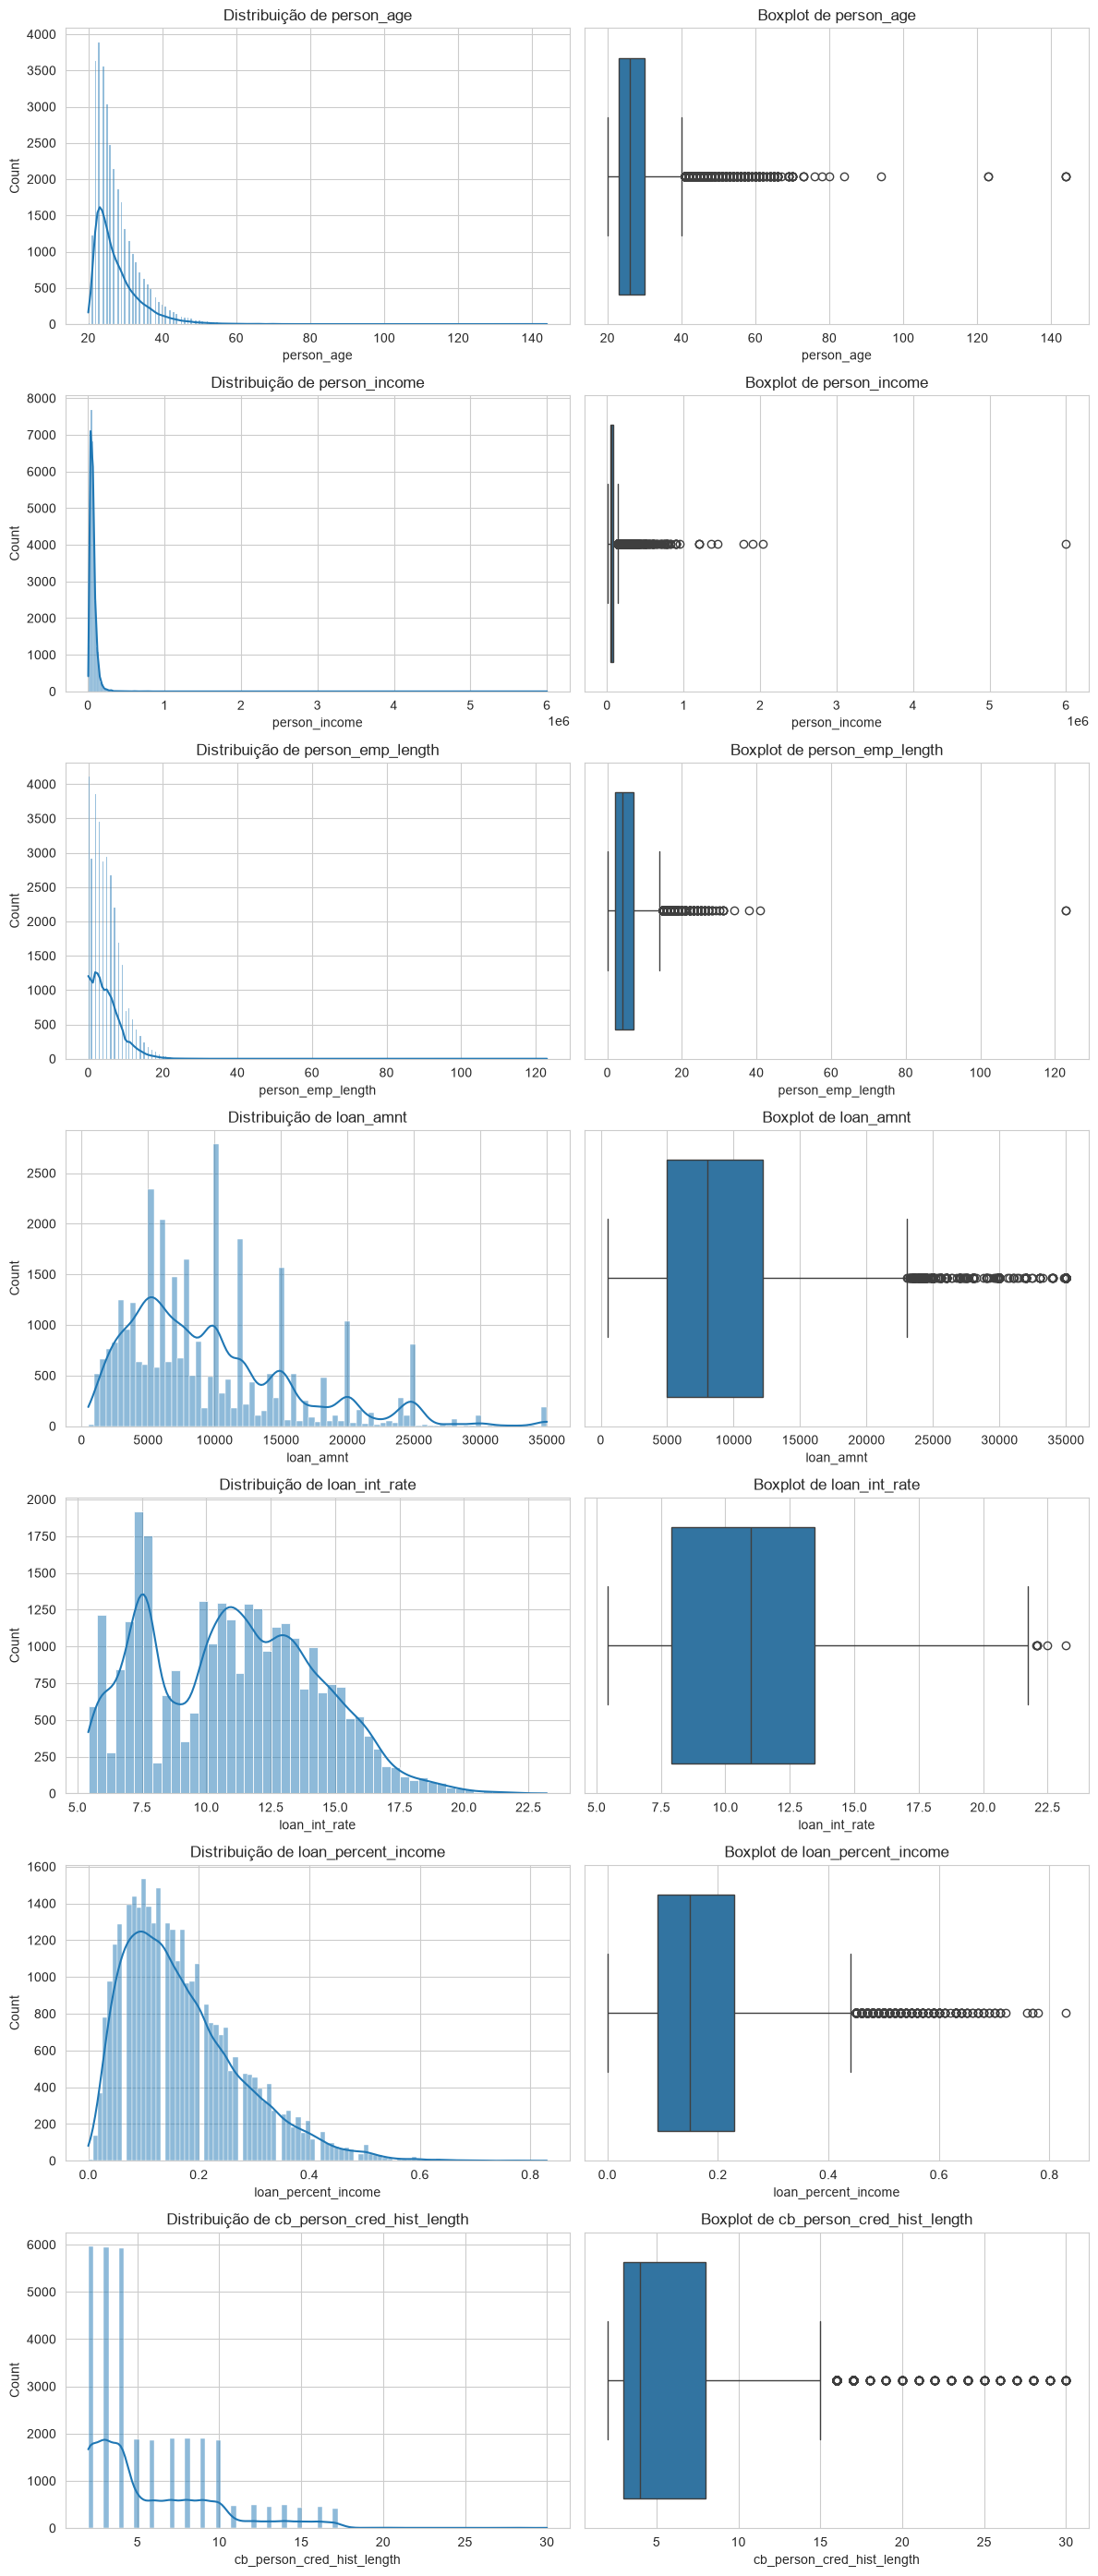

In [10]:
fig, axes = plt.subplots(len(variaveis_quantitativas), 2,
                          figsize=(12, 4 * len(variaveis_quantitativas)))
 
for i, col in enumerate(variaveis_quantitativas):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribuição de {col}")
 
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot de {col}")
 
plt.tight_layout()
plt.savefig("univariada_quantitativas.png", dpi=100)
plt.show()

### 6 - # Teste de normalidade

In [17]:
print("\nTeste de normalidade (Kolmogorov-Smirnov):")
for col in variaveis_quantitativas:
    dados = df[col].dropna()
    dados_padronizados = (dados - dados.mean()) / dados.std()
    stat, p_valor = stats.kstest(dados_padronizados, "norm")
    resultado = "Normal" if p_valor > 0.05 else "Não normal"
    print(f"  {col}: p-valor = {p_valor:.4f} -> {resultado}")


Teste de normalidade (Kolmogorov-Smirnov):
  person_age: p-valor = 0.0000 -> Não normal
  person_income: p-valor = 0.0000 -> Não normal
  person_emp_length: p-valor = 0.0000 -> Não normal
  loan_amnt: p-valor = 0.0000 -> Não normal
  loan_int_rate: p-valor = 0.0000 -> Não normal
  loan_percent_income: p-valor = 0.0000 -> Não normal
  cb_person_cred_hist_length: p-valor = 0.0000 -> Não normal


## 7 - Tratamento de outliers

In [16]:
# Identificação de outliers via IQR (regra clássica)
print("\nOutliers por variável (regra do IQR):")
for col in variaveis_quantitativas:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    n_outliers = df[(df[col] < limite_inferior) |
                     (df[col] > limite_superior)].shape[0]
    print(f"  {col}: {n_outliers} outliers "
          f"({100*n_outliers/len(df):.2f}% da base)")


Outliers por variável (regra do IQR):
  person_age: 1494 outliers (4.59% da base)
  person_income: 1484 outliers (4.55% da base)
  person_emp_length: 853 outliers (2.62% da base)
  loan_amnt: 1689 outliers (5.18% da base)
  loan_int_rate: 6 outliers (0.02% da base)
  loan_percent_income: 651 outliers (2.00% da base)
  cb_person_cred_hist_length: 1142 outliers (3.51% da base)


In [20]:
print("\n" + "=" * 60)
print("TRATAMENTO DE OUTLIERS")
print("=" * 60)
 
antes = len(df)

df_limpo = df[
    (df["person_age"] <= 100) &
    (df["person_emp_length"] <= 60)
].copy()
 
removidos = antes - len(df_limpo)
print(f"Linhas removidas (idade > 100 ou tempo de emprego > 60 anos): "
      f"{removidos} ({100*removidos/antes:.2f}% da base)")

# Reconfira as estatísticas depois da limpeza
print("\nEstatísticas de person_age e person_emp_length após remoção:")
print(df_limpo[["person_age", "person_emp_length"]].describe().T)


TRATAMENTO DE OUTLIERS
Linhas removidas (idade > 100 ou tempo de emprego > 60 anos): 902 (2.77% da base)

Estatísticas de person_age e person_emp_length após remoção:
                     count       mean       std   min   25%   50%   75%   max
person_age         31679.0  27.730673  6.213427  20.0  23.0  26.0  30.0  94.0
person_emp_length  31679.0   4.782064  4.034948   0.0   2.0   4.0   7.0  41.0


In [21]:
# --- (2) Valores extremos legítimos: person_income ---
# Em vez de remover, criamos uma versão transformada (log) para
# uso em análises/gráficos futuros. A coluna original é mantida.
df_limpo["person_income_log"] = np.log1p(df_limpo["person_income"])
# np.log1p = log(1 + x), evita problema se algum valor fosse 0

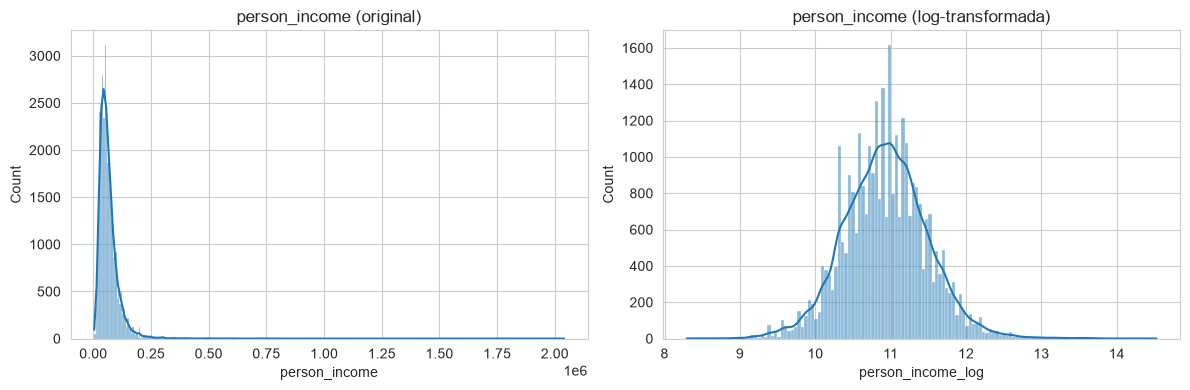


Assimetria de person_income (original):  9.82
Assimetria de person_income (log):        0.18


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_limpo["person_income"], kde=True, ax=axes[0])
axes[0].set_title("person_income (original)")
sns.histplot(df_limpo["person_income_log"], kde=True, ax=axes[1])
axes[1].set_title("person_income (log-transformada)")
plt.tight_layout()
plt.savefig("person_income_log.png", dpi=100)
plt.show()
 
print(f"\nAssimetria de person_income (original):  "
      f"{df_limpo['person_income'].skew():.2f}")
print(f"Assimetria de person_income (log):        "
      f"{df_limpo['person_income_log'].skew():.2f}")

In [23]:
# para trabalhar com a base já tratada.
df = df_limpo

## 8 - Analise univariada

In [24]:
# 3. ANÁLISE UNIVARIADA — VARIÁVEIS QUALITATIVAS
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("TABELAS DE FREQUÊNCIA — VARIÁVEIS QUALITATIVAS")
print("=" * 60)
 
for col in variaveis_qualitativas:
    print(f"\n--- {col} ---")
    freq_abs = df[col].value_counts()
    freq_rel = df[col].value_counts(normalize=True) * 100
    tabela = pd.DataFrame({"Frequência": freq_abs,
                            "Percentual (%)": freq_rel.round(2)})
    print(tabela)


TABELAS DE FREQUÊNCIA — VARIÁVEIS QUALITATIVAS

--- person_home_ownership ---
                       Frequência  Percentual (%)
person_home_ownership                            
RENT                        16072           50.73
MORTGAGE                    13090           41.32
OWN                          2410            7.61
OTHER                         107            0.34

--- loan_intent ---
                   Frequência  Percentual (%)
loan_intent                                  
EDUCATION                6288           19.85
MEDICAL                  5897           18.61
VENTURE                  5553           17.53
PERSONAL                 5367           16.94
DEBTCONSOLIDATION        5064           15.99
HOMEIMPROVEMENT          3510           11.08

--- loan_grade ---
            Frequência  Percentual (%)
loan_grade                            
A                10370           32.73
B                10183           32.14
C                 6319           19.95
D                

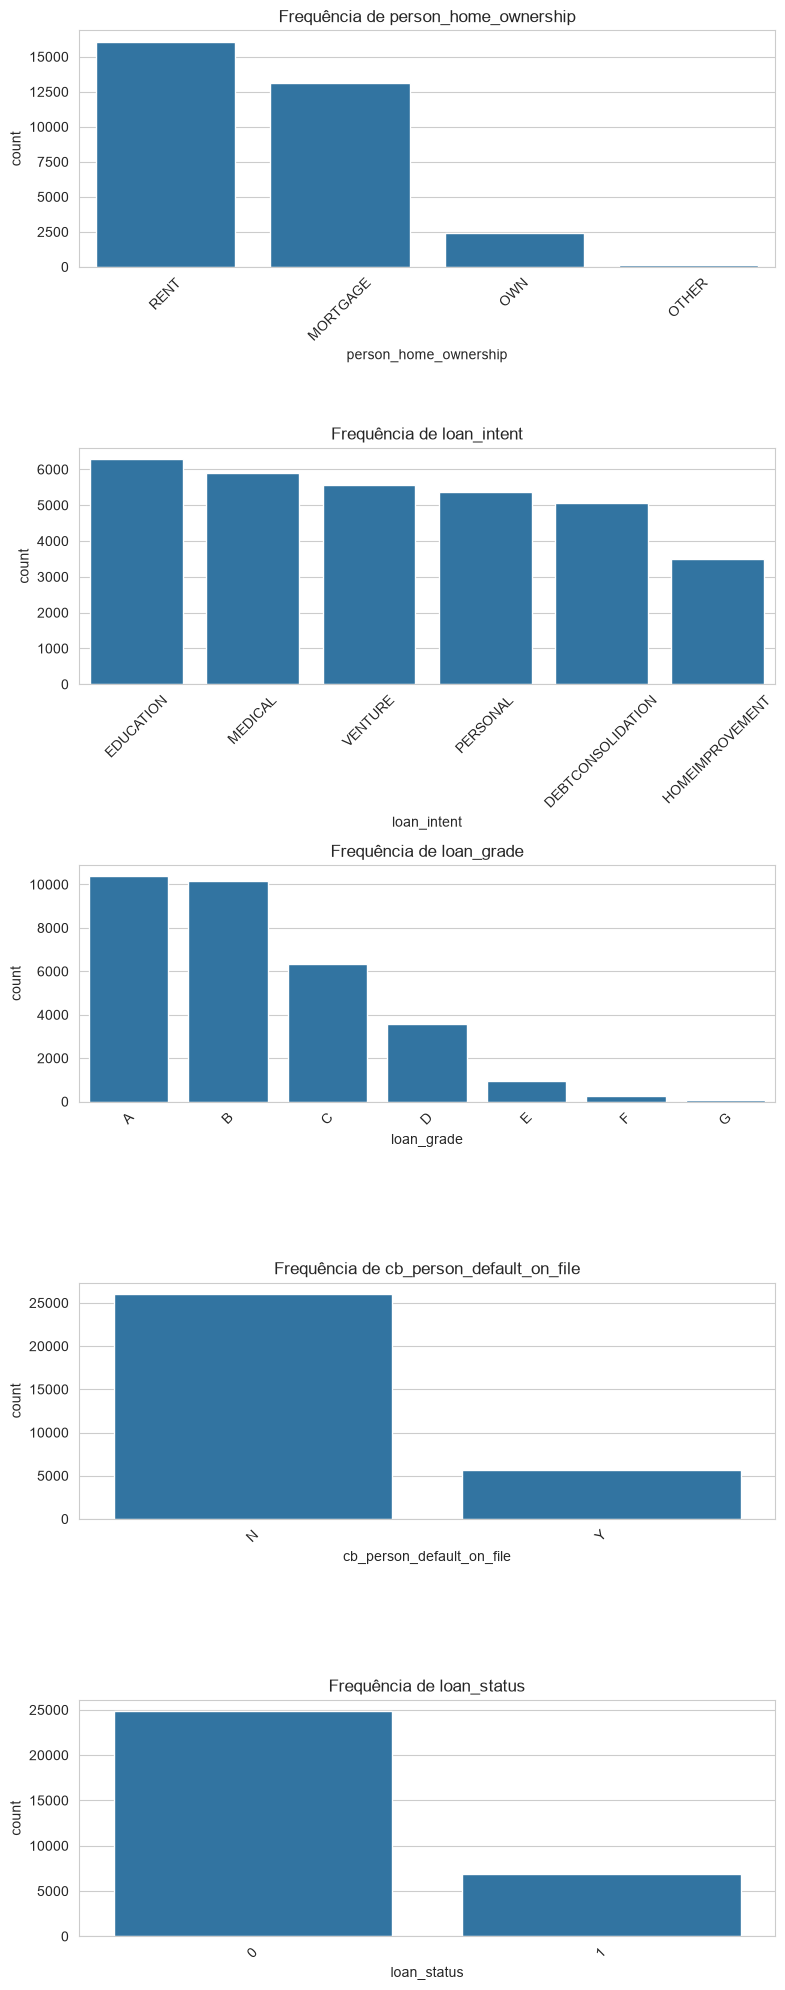

In [25]:
# Gráficos de barras para as qualitativas
fig, axes = plt.subplots(len(variaveis_qualitativas), 1,
                          figsize=(8, 4 * len(variaveis_qualitativas)))
 
for i, col in enumerate(variaveis_qualitativas):
    ordem = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=ordem, ax=axes[i])
    axes[i].set_title(f"Frequência de {col}")
    axes[i].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.savefig("univariada_qualitativas.png", dpi=100)
plt.show()

person_home_ownership — mais da metade dos solicitantes mora de aluguel (50,7%), seguido por financiamento/hipoteca (41,3%). Só 7,6% têm imóvel próprio quitado. Isso é uma variável que provavelmente terá poder preditivo forte sobre risco de crédito (quem já tem patrimônio quitado tende a ser menos arriscado) — vale testar isso na fase multivariada. OTHER é quase residual (0,34%), então numa modelagem futura pode fazer sentido agrupá-la com outra categoria pequena para não virar ruído no modelo.

loan_intent — bem distribuída entre as 6 finalidades, sem nenhuma categoria dominando isoladamente (de 11% a quase 20%). Não há motivo de alarme aqui — é uma variável "saudável" em termos de balanceamento interno.

loan_grade — forte concentração nas notas melhores: A+B somam quase 65% da base, enquanto E+F+G (as faixas de maior risco) somam menos de 4%. Isso é esperado — bancos concedem menos crédito para os perfis de maior risco. Mas do ponto de vista de modelagem, essa também é uma variável desbalanceada internamente: se você quiser usar loan_grade como variável explicativa de algo, categorias como F e G terão poucas observações para o modelo "aprender" um padrão confiável sobre elas.

cb_person_default_on_file — 82,2% nunca tiveram default registrado, 17,8% já tiveram. Isso por si só já é um forte candidato a variável preditora de loan_status — vale cruzar as duas no próximo estágio (multivariada) para confirmar a associação.

loan_status (variável-alvo) — aqui está a confirmação formal do desbalanceamento que já intuíamos lá no início: 78,46% adimplentes (0) vs. 21,54% inadimplentes (1), uma razão de aproximadamente 3,6 : 1. Isso já responde tecnicamente a etapa de balanceamento de classes (passo 4 do script) — o resultado que você tem aqui é exatamente o que a seção 4 do script calcularia formalmente, com a razão de desbalanceamento.

## 9 - Balanceamento de classes

In [27]:
# ------------------------------------------------------------
# 4. BALANCEAMENTO DE CLASSES (variável-alvo: loan_status)
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("BALANCEAMENTO DE CLASSES — loan_status")
print("=" * 60)
 
balanceamento = df["loan_status"].value_counts(normalize=True) * 100
print(balanceamento)
print("\n0 = adimplente (pagou) | 1 = inadimplente (default)")
 
razao_desbalanceamento = (df["loan_status"].value_counts()[0] /
                           df["loan_status"].value_counts()[1])
print(f"\nRazão de desbalanceamento (maioria/minoria): "
      f"{razao_desbalanceamento:.2f} : 1")


BALANCEAMENTO DE CLASSES — loan_status
loan_status
0    78.455759
1    21.544241
Name: proportion, dtype: float64

0 = adimplente (pagou) | 1 = inadimplente (default)

Razão de desbalanceamento (maioria/minoria): 3.64 : 1


## 10 - Cálculo do tamanho minimo da amostra

In [28]:
# ------------------------------------------------------------
# 5. CÁLCULO DO TAMANHO MÍNIMO DE AMOSTRA
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("CÁLCULO DE TAMANHO DE AMOSTRA")
print("=" * 60)
 
N = len(df)  # tamanho da população
 
# --- 5a. Para proporção (ex: estimar a taxa de default) ---
Z = 1.96          # 95% de confiança
p = df["loan_status"].mean()   # proporção observada de default (calculada aqui,
                                # não depende do passo 4 ter sido executado)
E = 0.02          # margem de erro de 2 pontos percentuais
 
n_proporcao = (Z**2 * p * (1 - p)) / (E**2)
n_proporcao_ajustado = n_proporcao / (1 + (n_proporcao - 1) / N)
 
print(f"Amostra p/ estimar proporção de default (E=2%, 95% conf.): "
      f"{n_proporcao:.0f} (bruto) / {n_proporcao_ajustado:.0f} "
      f"(corrigido p/ população finita)")


CÁLCULO DE TAMANHO DE AMOSTRA
Amostra p/ estimar proporção de default (E=2%, 95% conf.): 1623 (bruto) / 1544 (corrigido p/ população finita)


In [29]:
# --- 5b. Para média (ex: estimar renda média) ---
sigma = df["person_income"].std()
E_renda = 1000   # margem de erro de R$ 1.000
 
n_media = (Z * sigma / E_renda) ** 2
n_media_ajustado = n_media / (1 + (n_media - 1) / N)
 
print(f"Amostra p/ estimar renda média (E=R$1.000, 95% conf.): "
      f"{n_media:.0f} (bruto) / {n_media_ajustado:.0f} (corrigido)")
 

Amostra p/ estimar renda média (E=R$1.000, 95% conf.): 10697 (bruto) / 7997 (corrigido)


## 11 - SORTEAR A AMOSTRA E COMPARAR COM A POPULAÇÃO

In [31]:
# ------------------------------------------------------------
# 6. SORTEAR A AMOSTRA E COMPARAR COM A POPULAÇÃO
# ------------------------------------------------------------
n_final = int(round(n_proporcao_ajustado))
 
# Amostra aleatória simples
amostra_simples = df.sample(n=n_final, random_state=42)
 
# Amostra aleatória estratificada por loan_status
# (garante a mesma proporção de default da população na amostra)
#
# Observação: evitamos groupby().apply() aqui de propósito -- a partir
# do pandas 2.2+, apply() passa a excluir por padrão a própria coluna
# de agrupamento de dentro da função aplicada, o que causaria um
# KeyError ao tentar usar 'loan_status' depois. Iterar sobre os grupos
# e concatenar é mais explícito e não depende desse comportamento.
amostra_estratificada = pd.concat([
    grupo.sample(frac=n_final / N, random_state=42)
    for _, grupo in df.groupby("loan_status")
])
 
print("\nComparação: proporção de default (população vs amostras)")
print(f"  População:              {df['loan_status'].mean()*100:.2f}%")
print(f"  Amostra simples:        "
      f"{amostra_simples['loan_status'].mean()*100:.2f}%")
print(f"  Amostra estratificada:  "
      f"{amostra_estratificada['loan_status'].mean()*100:.2f}%")
 
print("\nComparação: renda média (população vs amostras)")
print(f"  População:              R$ {df['person_income'].mean():.2f}")
print(f"  Amostra simples:        "
      f"R$ {amostra_simples['person_income'].mean():.2f}")
print(f"  Amostra estratificada:  "
      f"R$ {amostra_estratificada['person_income'].mean():.2f}")
 


Comparação: proporção de default (população vs amostras)
  População:              21.54%
  Amostra simples:        20.40%
  Amostra estratificada:  21.57%

Comparação: renda média (população vs amostras)
  População:              R$ 66490.10
  Amostra simples:        R$ 67160.59
  Amostra estratificada:  R$ 65741.41


a estratificação só melhora a precisão da variável que você usou como critério de estratificação. Se o seu objetivo principal numa auditoria é garantir que a taxa de inadimplência da amostra reflita fielmente a da carteira toda, estratificar por loan_status é a escolha certa. Mas se o foco fosse estimar a renda média com precisão, o ideal seria estratificar por faixas de renda (ex: quartis de person_income) em vez de por status de default.

In [ ]:
# ============================================================
# RESUMO DE ESTUDO — Análise Univariada, Outliers, Amostragem
# e Balanceamento de Classes
# ============================================================
#
# --- CONCEITOS ---
#
# .describe().T
#   .describe() gera um resumo estatístico (count, mean, std, min,
#   quartis, max) com 1 VARIÁVEL POR COLUNA. .T (transpose) inverte
#   linhas por colunas, deixando 1 variável por LINHA -- mais fácil
#   de ler quando há várias variáveis.
#
# Assimetria (skew)
#   Mede se a distribuição é simétrica ou "puxada" para um lado.
#   ~0 = simétrica | >0 = cauda longa à direita (valores altos raros
#   puxando a média p/ cima) | <0 = cauda longa à esquerda.
#   Quando a assimetria é alta, a MEDIANA representa melhor o "valor
#   típico" do que a média (que fica distorcida pelos extremos).
#
# Curtose (kurt)
#   Mede o quão "pesadas" são as caudas em relação à normal (ou seja,
#   o quanto há valores extremos). ~0 = parecida com a normal |
#   >0 = mais outliers que uma normal | <0 = mais achatada, menos
#   outliers extremos.
#
# Teste de normalidade (Kolmogorov-Smirnov)
#   Verifica estatisticamente se uma variável segue distribuição
#   normal. p-valor > 0.05 -> não há evidência contra a normalidade
#   (trata-se como normal) | p-valor <= 0.05 -> distribuição
#   significativamente diferente da normal.
#
# Outliers -- duas categorias, dois tratamentos:
#   1) Erro de dado (fisicamente impossível, ex: idade 144 anos)
#      -> REMOVER, com limite definido por bom senso de domínio,
#      não só pela regra estatística do IQR.
#   2) Valor extremo mas legítimo (ex: renda de R$6 milhões existe
#      de fato) -> NÃO remover. Transformar (ex: log) ou usar
#      estatísticas robustas (mediana em vez de média).
#
# Transformação logarítmica (np.log1p)
#   Comprime a escala de variáveis monetárias fortemente assimétricas,
#   aproximando a distribuição de uma normal. Não apaga os dados --
#   só muda a escala em que são vistos/modelados.
#
# Cálculo de tamanho mínimo de amostra
#   Para PROPORÇÃO:  n = Z² · p(1-p) / E²
#   Para MÉDIA:      n = (Z · σ / E)²
#   Correção p/ população finita: n_ajustado = n / (1 + (n-1)/N)
#   Z = nível de confiança (1,96 = 95%) | E = margem de erro tolerada
#   | p = proporção esperada | σ = desvio-padrão da população
#
# Amostragem simples vs. estratificada
#   A estratificação só melhora a precisão da variável usada como
#   CRITÉRIO de estratificação. Estratificar por loan_status deixa a
#   proporção de default quase idêntica à da população -- mas não dá
#   nenhuma vantagem extra para estimar outras variáveis (ex: renda),
#   que continuam sujeitas à variação normal do sorteio aleatório.
#
#
# --- RESULTADOS OBTIDOS NESTA EXECUÇÃO (Credit Risk Dataset) ---
#
# Outliers removidos: 902 linhas (2,77% da base) por person_age > 100
#   ou person_emp_length > 60 anos -- erros de dado, não valores reais.
#
# person_income: assimetria caiu de 9,82 (original) para 0,18
#   (log-transformada) -- exemplo claro de quando log resolve.
#
# Balanceamento de loan_status: 78,46% adimplentes (0) vs. 21,54%
#   inadimplentes (1) -- razão de desbalanceamento 3,64:1 (moderado,
#   não exige técnicas agressivas como undersampling pesado).
#
# Tamanho de amostra calculado (95% confiança):
#   - p/ estimar proporção de default (E=2%): ~1.544 observações
#   - p/ estimar renda média (E=R$1.000): ~7.997 observações
#     (bem maior por causa do desvio-padrão alto de person_income)
#
# Amostra simples vs. estratificada (n=1.544, sobre N=31.679):
#   - Proporção de default: população 21,54% | simples 20,40%
#     (desvio 1,14pp) | estratificada 21,57% (desvio 0,03pp)
#   - Renda média: população R$66.490 | simples R$67.161
#     (desvio ~R$670) | estratificada R$65.741 (desvio ~R$749)
#   -> Confirma a lição acima: estratificar por loan_status deixou a
#      proporção de default quase perfeita, mas não ajudou (nem
#      atrapalhou) a precisão da renda média.
# ============================================================